# Build the Monthly Returns Dataset


**Data source:** Nasdaq Data Link / SHARADAR

**Tables used:**
- `sep` — daily stock prices: `close` (split-adjusted), `closeadj` (split + dividend-adjusted)
- `daily` — daily market data: `marketcap` (in millions of USD)
- `tickers` — reference data: `sector`, `industry`

**Universe:** All NYSE & Nasdaq listed common stocks (including delisted — avoids survivorship bias)  
**Sample period:** January 2021 – January 2026  

> SQL queries are run **one year at a time** to avoid API timeouts.  
> A self-join filters to the **last trading day of each calendar month** before returning results.

In [ ]:
# ── Colab: install any missing packages ───────────────────────────────────────
# Uncomment the next line if running on Google Colab
!pip install -q requests pandas numpy matplotlib

## Cell 1 — Imports & Query Helper

In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import getpass
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.4f}'.format)

PORTAL_URL = 'https://data-portal.rice-business.org/api/query'

# ── Enter your Rice Database access token ─────────────────────────────────────
TOKEN = getpass.getpass('Paste your Rice Database access token: ')

def query_rice(sql, timeout=300):
    """POST a SQL query to the Rice Business Database and return a DataFrame."""
    headers = {
        'Authorization': f'Bearer {TOKEN}',
        'Content-Type':  'application/json',
    }
    resp = requests.post(
        PORTAL_URL,
        json={'query': sql},
        headers=headers,
        timeout=timeout,
    )
    resp.raise_for_status()
    payload = resp.json()
    df = pd.DataFrame(payload['data'])
    if 'columns' in payload and not df.empty:
        df = df[payload['columns']]
    return df

print('Ready.')

Paste your Rice Database access token: ··········
Ready.


## Cell 2 — Sector & Industry from `tickers` Table

In [ ]:
tickers_df = query_rice('SELECT ticker, sector, industry FROM tickers')

print(f'Tickers with metadata: {len(tickers_df):,}')
print(tickers_df['sector'].value_counts().head(10))

Tickers with metadata: 15,423
sector
Technology                2904
Healthcare                2571
Industrials               2380
Financial Services        2306
Consumer Cyclical         1566
Communication Services     831
Energy                     721
Basic Materials            681
Real Estate                604
Consumer Defensive         597
Name: count, dtype: int64


## Cell 3 — Define Fetch Helpers

Each helper queries one date window.  A self-join identifies the **last trading day** of each calendar month per ticker, reducing API payload by ~95% vs. fetching all daily rows.

**`sep` columns returned:**  
- `close` — split-adjusted (used for penny-stock filter)  
- `closeadj` — split + dividend-adjusted (used for return / momentum)  

**`daily` columns returned:**  
- `marketcap` — market cap in millions of USD

In [ ]:
def fetch_sep_monthly(start, end, label):
    """Query sep for month-end close and closeadj within [start, end]."""
    print(f'[{label}] Fetching SEP...', flush=True)
    sql = (
        "SELECT s.ticker, s.date, s.close, s.closeadj "
        "FROM sep s "
        "INNER JOIN ("
        "    SELECT ticker, MAX(date) AS last_day "
        "    FROM sep "
        f"   WHERE date >= '{start}' AND date <= '{end}' "
        "    GROUP BY ticker, DATE_TRUNC('month', CAST(date AS DATE))"
        ") t ON s.ticker = t.ticker AND s.date = t.last_day "
        f"WHERE s.date >= '{start}' AND s.date <= '{end}' "
        "ORDER BY s.ticker, s.date"
    )
    df = query_rice(sql)
    df['date']     = pd.to_datetime(df['date'])
    df['close']    = pd.to_numeric(df['close'],    errors='coerce')
    df['closeadj'] = pd.to_numeric(df['closeadj'], errors='coerce')
    print(f'    rows={len(df):,}  tickers={df["ticker"].nunique():,}', flush=True)
    return df


def fetch_daily_monthly(start, end, label):
    """Query daily for month-end marketcap within [start, end]."""
    print(f'[{label}] Fetching Daily (marketcap)...', flush=True)
    sql = (
        "SELECT d.ticker, d.date, d.marketcap "
        "FROM daily d "
        "INNER JOIN ("
        "    SELECT ticker, MAX(date) AS last_day "
        "    FROM daily "
        f"   WHERE date >= '{start}' AND date <= '{end}' "
        "    GROUP BY ticker, DATE_TRUNC('month', CAST(date AS DATE))"
        ") t ON d.ticker = t.ticker AND d.date = t.last_day "
        f"WHERE d.date >= '{start}' AND d.date <= '{end}' "
        "ORDER BY d.ticker, d.date"
    )
    df = query_rice(sql)
    df['date']      = pd.to_datetime(df['date'])
    df['marketcap'] = pd.to_numeric(df['marketcap'], errors='coerce')
    print(f'    rows={len(df):,}  tickers={df["ticker"].nunique():,}', flush=True)
    return df

print('Fetch helpers defined.')

Fetch helpers defined.


## Cell 4 — Fetch Data: Jan 2021 – Jan 2026

Data is fetched year-by-year to stay within the API's timeout limits.

In [ ]:
sep_2021   = fetch_sep_monthly('2021-01-01', '2021-12-31', '2021')
daily_2021 = fetch_daily_monthly('2021-01-01', '2021-12-31', '2021')

[2021] Fetching SEP...
    rows=59,901  tickers=5,510
[2021] Fetching Daily (marketcap)...
    rows=59,880  tickers=5,509


In [ ]:
sep_2022   = fetch_sep_monthly('2022-01-01', '2022-12-31', '2022')
daily_2022 = fetch_daily_monthly('2022-01-01', '2022-12-31', '2022')

[2022] Fetching SEP...
    rows=62,573  tickers=5,406
[2022] Fetching Daily (marketcap)...
    rows=62,549  tickers=5,404


In [ ]:
sep_2023   = fetch_sep_monthly('2023-01-01', '2023-12-31', '2023')
daily_2023 = fetch_daily_monthly('2023-01-01', '2023-12-31', '2023')

[2023] Fetching SEP...
    rows=57,980  tickers=5,141
[2023] Fetching Daily (marketcap)...
    rows=57,966  tickers=5,140


In [ ]:
sep_2024   = fetch_sep_monthly('2024-01-01', '2024-12-31', '2024')
daily_2024 = fetch_daily_monthly('2024-01-01', '2024-12-31', '2024')

[2024] Fetching SEP...
    rows=53,980  tickers=4,768
[2024] Fetching Daily (marketcap)...
    rows=53,973  tickers=4,768


In [ ]:
sep_2025_2026   = fetch_sep_monthly('2025-01-01', '2026-01-31', '2025-2026')
daily_2025_2026 = fetch_daily_monthly('2025-01-01', '2026-01-31', '2025-2026')

[2025-2026] Fetching SEP...
    rows=56,328  tickers=4,668
[2025-2026] Fetching Daily (marketcap)...
    rows=56,325  tickers=4,668


## Cell 5 — Concatenate, Merge, and Add Metadata

In [ ]:
# Concatenate SEP and DAILY chunks
sep_all = (
    pd.concat([sep_2021, sep_2022, sep_2023, sep_2024, sep_2025_2026], ignore_index=True)
    .drop_duplicates(subset=['ticker', 'date'])
    .sort_values(['ticker', 'date'])
    .reset_index(drop=True)
)

daily_all = (
    pd.concat([daily_2021, daily_2022, daily_2023, daily_2024, daily_2025_2026], ignore_index=True)
    .drop_duplicates(subset=['ticker', 'date'])
    .sort_values(['ticker', 'date'])
    .reset_index(drop=True)
)

# Merge SEP + DAILY on (ticker, date)
df = pd.merge(sep_all, daily_all[['ticker', 'date', 'marketcap']], on=['ticker', 'date'], how='left')

# Add sector and industry from tickers metadata
df = pd.merge(df, tickers_df[['ticker', 'sector', 'industry']], on='ticker', how='left')

# Add month label (YYYY-MM)
df['month'] = df['date'].dt.to_period('M').astype(str)

print(f'SEP total:    {len(sep_all):,} rows | {sep_all["ticker"].nunique():,} tickers')
print(f'Daily total:  {len(daily_all):,} rows | {daily_all["ticker"].nunique():,} tickers')
print(f'Merged panel: {len(df):,} rows')
print(f'Date range:   {df["date"].min().date()} to {df["date"].max().date()}')

SEP total:    290,762 rows | 6,324 tickers
Daily total:  290,693 rows | 6,324 tickers
Merged panel: 290,762 rows
Date range:   2021-01-04 to 2026-01-30


## Cell 6 — Compute Returns, Momentum, and Lagged Return

All calculations are grouped **by ticker** to prevent mixing data across stocks.

| Variable | Formula |
|---|---|
| `return` | $r_t = \frac{\text{closeadj}_t}{\text{closeadj}_{t-1}} - 1$ |
| `momentum` | $\frac{\text{closeadj}_{t-2}}{\text{closeadj}_{t-13}} - 1$ (12-month return, skipping most recent month) |
| `lag_month` | $r_{t-1}$ |

In [ ]:
df = df.sort_values(['ticker', 'date']).reset_index(drop=True)

# Monthly return
df['return'] = df.groupby('ticker')['closeadj'].pct_change().round(4)

# Momentum: closeadj_{t-2} / closeadj_{t-13} - 1
df['momentum'] = (
    df.groupby('ticker')['closeadj'].shift(2) /
    df.groupby('ticker')['closeadj'].shift(13)
    - 1
).round(4)

# Lagged return
df['lag_month'] = df.groupby('ticker')['return'].shift(1).round(4)

print('Returns, momentum, and lagged return computed.')

Returns, momentum, and lagged return computed.


## Cell 7 — Shift Marketcap & Assign Size Categories

Marketcap is **shifted forward by 1 month** (grouped by ticker) to avoid look-ahead bias — the size label for month $t$ reflects the marketcap measured at the end of month $t-1$.

Size categories are assigned by cross-sectional marketcap percentile within each month, matching the Fama-French / CRSP convention used in the Rice Data Portal.

In [ ]:
# Shift marketcap by 1 month within each ticker (avoid look-ahead bias)
df['marketcap'] = df.groupby('ticker')['marketcap'].shift(1)

# Cross-sectional percentile rank within each month
df['_pct'] = df.groupby('month')['marketcap'].rank(pct=True, method='average') * 100

df['size'] = pd.cut(
    df['_pct'],
    bins=[0, 3.34, 18.83, 51.46, 78.60, 98.53, 100],
    labels=['Nano-Cap', 'Micro-Cap', 'Small-Cap', 'Mid-Cap', 'Large-Cap', 'Mega-Cap'],
    include_lowest=True
).astype(str)

df.loc[df['marketcap'].isna(), 'size'] = None
df = df.drop(columns=['_pct'])

# Final column order (drop closeadj from output)
df = df[['ticker', 'month', 'date', 'close', 'return', 'momentum', 'lag_month',
         'industry', 'sector', 'marketcap', 'size']]

print('Marketcap shifted and size categories assigned.')
df.head()

Marketcap shifted and size categories assigned.


,ticker,month,date,close,return,momentum,lag_month,industry,sector,marketcap,size
0,A,2021-01,2021-01-29,120.1700,NaN,NaN,NaN,Diagnostics & Research,Healthcare,NaN,None
1,A,2021-02,2021-02-26,122.0700,0.0158,NaN,NaN,Diagnostics & Research,Healthcare,"36,874.1000",Large-Cap
2,A,2021-03,2021-03-31,127.1400,0.0415,NaN,0.0158,Diagnostics & Research,Healthcare,"37,457.1000",Large-Cap
3,A,2021-04,2021-04-30,133.6400,0.0527,NaN,0.0415,Diagnostics & Research,Healthcare,"38,739.2000",Large-Cap
4,A,2021-05,2021-05-28,138.1300,0.0336,NaN,0.0527,Diagnostics & Research,Healthcare,"40,719.8000",Large-Cap


---
## Question 1 — Total Rows, Unique Tickers, and Date Range

In [ ]:
n_rows    = len(df)
n_tickers = df['ticker'].nunique()
date_min  = df['date'].min().date()
date_max  = df['date'].max().date()
n_months  = df['month'].nunique()

print('=' * 55)
print(f'  Total rows:         {n_rows:>12,}')
print(f'  Unique tickers:     {n_tickers:>12,}')
print(f'  Date range:         {date_min}  to  {date_max}')
print(f'  Months in sample:   {n_months:>12,}')
print('=' * 55)

  Total rows:              290,762
  Unique tickers:            6,324
  Date range:         2021-01-04  to  2026-01-30
  Months in sample:             61


---
## Question 2 — Penny-Stock Filter: Rows Lost When `close < $5`

In [ ]:
n_before     = len(df)
penny_mask   = df['close'] < 5
n_penny      = penny_mask.sum()
n_after      = n_before - n_penny
pct_dropped  = n_penny / n_before * 100

print(f'Rows before penny-stock filter:  {n_before:>10,}')
print(f'Rows dropped  (close < $5):      {n_penny:>10,}  ({pct_dropped:.1f}%)')
print(f'Rows remaining:                  {n_after:>10,}')

df_filtered = df[~penny_mask].copy().reset_index(drop=True)

Rows before penny-stock filter:     290,762
Rows dropped  (close < $5):          47,337  (16.3%)
Rows remaining:                     243,425


---
## Question 3 — Fraction of Stock-Months with Missing Momentum

Total stock-months:                  290,762
Missing momentum:                     78,348
Fraction missing:                     0.2695  (26.95%)


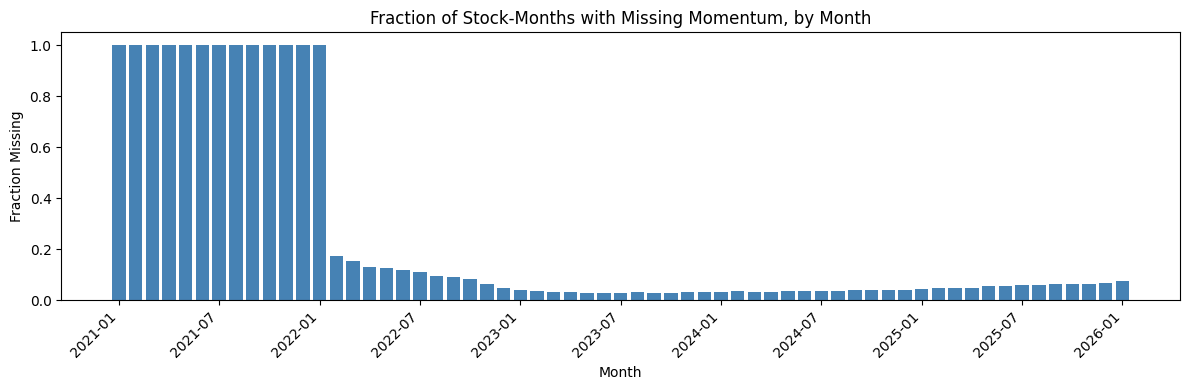

Chart saved to missing_momentum_by_month.png


In [ ]:
n_total          = len(df)
n_missing_mom    = df['momentum'].isna().sum()
frac_missing     = n_missing_mom / n_total

print(f'Total stock-months:               {n_total:>10,}')
print(f'Missing momentum:                 {n_missing_mom:>10,}')
print(f'Fraction missing:                 {frac_missing:>10.4f}  ({frac_missing*100:.2f}%)')

# Break down missing momentum by month to show it's concentrated in early periods
missing_by_month = (
    df.groupby('month')['momentum']
    .apply(lambda s: s.isna().mean())
    .reset_index(name='frac_missing')
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(missing_by_month['month'], missing_by_month['frac_missing'], color='steelblue')
ax.set_title('Fraction of Stock-Months with Missing Momentum, by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Fraction Missing')
ax.set_xticks(ax.get_xticks()[::6])   # label every 6 months
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('missing_momentum_by_month.png', dpi=150)
plt.show()
print('Chart saved to missing_momentum_by_month.png')

### Why is momentum missing for early observations?

Momentum for month $t$ is defined as the cumulative return from 13 months ago to 2 months ago:

$$\text{momentum}_t = \frac{\text{closeadj}_{t-2}}{\text{closeadj}_{t-13}} - 1$$

Computing this requires **13 prior monthly price observations** per ticker.  Because our dataset starts in **January 2021**, any ticker whose price history within the dataset is shorter than 13 months cannot have momentum calculated — there is no `closeadj_{t-13}` value available.

Concretely:
- **January 2021** observations: `shift(13)` would require December 2019 prices — not in our dataset → momentum is **NaN for all tickers**.
- **February – December 2021** observations: `shift(13)` falls within Jan 2020 – Nov 2020, still outside our dataset → momentum is **NaN for all tickers**.
- **January 2022** (`shift(13)` = Dec 2020): first month where any ticker *could* have valid momentum, but only for tickers present since at least Dec 2020 in the data — which is still outside our Jan 2021 start.
- **February 2022** onward: `shift(13)` begins to fall within Jan 2021 data → momentum becomes available for tickers that were present continuously since the start of our sample.

The bar chart above confirms this pattern: missing momentum is **100% for the first ~13 months** of the sample, then drops sharply and stabilises at a low residual rate driven by newly listed or recently delisted tickers that lack 13 consecutive monthly prices.

---
## Cell 8 — Save Final Dataset

In [ ]:
output_file = 'monthly_returns_2021_2026.parquet'
df.to_parquet(output_file, index=False)
print(f'Saved {len(df):,} rows to {output_file}')
df.head()

Saved 290,762 rows to monthly_returns_2021_2026.parquet


,ticker,month,date,close,return,momentum,lag_month,industry,sector,marketcap,size
0,A,2021-01,2021-01-29,120.1700,NaN,NaN,NaN,Diagnostics & Research,Healthcare,NaN,None
1,A,2021-02,2021-02-26,122.0700,0.0158,NaN,NaN,Diagnostics & Research,Healthcare,"36,874.1000",Large-Cap
2,A,2021-03,2021-03-31,127.1400,0.0415,NaN,0.0158,Diagnostics & Research,Healthcare,"37,457.1000",Large-Cap
3,A,2021-04,2021-04-30,133.6400,0.0527,NaN,0.0415,Diagnostics & Research,Healthcare,"38,739.2000",Large-Cap
4,A,2021-05,2021-05-28,138.1300,0.0336,NaN,0.0527,Diagnostics & Research,Healthcare,"40,719.8000",Large-Cap
